## Data generation

### Import and setup

In [1]:
# Importing necessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Set a random seed for reproducible results

np.random.seed(42)

### Simulating data

In this simulation I am generating data for every user in the experiment for both states of the world (A and B).

If a user sees version A, they will have a cost associated with version A, and if they see version B, they will have a cost associated with version B.

We only are able to observe one of these costs for each user, so we can not have counterfactuals and so individual-level causal effects can not be directly estimated for each user either.

However, we can estimate the average treatment effect (ATE) across all users in the experiment by assigning users to either version A or version B and then comparing the average costs or other outcomes between the two groups.


In [3]:
# Number of total users to simulate

total_n = 20000

In [4]:
# Cost difference: Group B is expected to have a lower estimated cost

target_cost_diff = 2000  # Target difference in estimated costs between Group B and Group A

target_cost_A = 5500  # Estimated cost for Group A
target_cost_B = target_cost_A - target_cost_diff  # Estimated cost for Group B

In [5]:
# Difference in standard deviations: Group B is expected to have a smaller standard deviation in costs

sigma_A = 0.55 # Standard deviation for the log-normal distribution in Group A
mu_A = np.log(target_cost_A) - (sigma_A**2 / 2) # Mean for the log-normal distribution of Group A costs

sigma_B = 0.35 # Standard deviation for the log-normal distribution in Group B
mu_B = np.log(target_cost_B) - (sigma_B**2 / 2) # Mean for the log-normal distribution of Group B costs

In [6]:
costs_A = np.random.lognormal(mean = mu_A, sigma = sigma_A, size = total_n)
costs_B = np.random.lognormal(mean = mu_B, sigma = sigma_B, size = total_n)

### The dataset

In [7]:
df = pd.DataFrame({'id': range(1, total_n + 1)})

df['id'] = 'id_' + df['id'].astype(str)

In [8]:
df = df.join(pd.DataFrame(costs_A, columns = ['version_a']), how = 'outer').join(pd.DataFrame(costs_B, columns = ['version_b']), how = 'outer')

In [9]:
df

,id,version_a,version_b
0,id_1,6213.292051,3718.845071
1,id_2,4381.769887,3635.243971
2,id_3,6751.244027,2371.994168
3,id_4,10926.210254,4032.423041
4,id_5,4156.667769,1954.206116
...,...,...,...
19995,id_19996,5852.114976,4871.446056
19996,id_19997,10085.005437,3612.047860
19997,id_19998,5821.702678,4084.863581
19998,id_19999,12133.126552,4378.171604


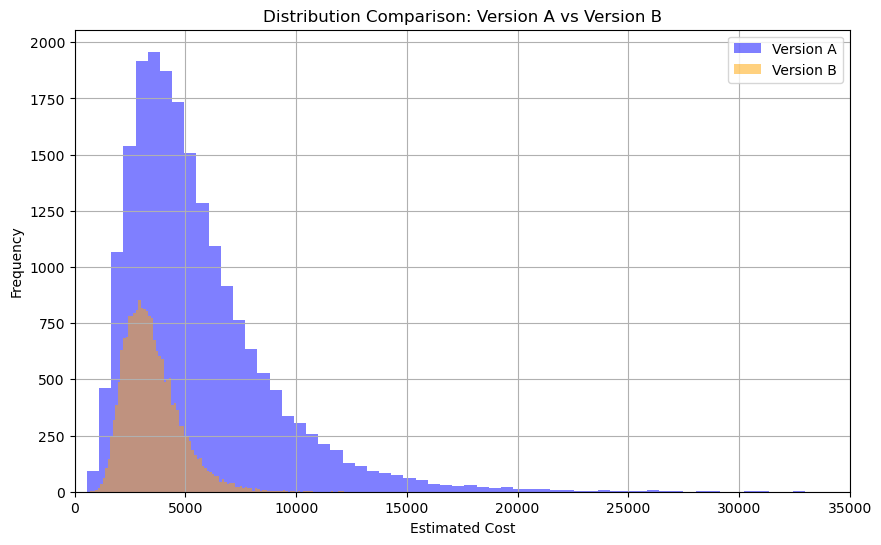

In [10]:
plt.figure(figsize = (10, 6))

df['version_a'].hist(bins = 100, alpha = 0.5, label = 'Version A', color = 'blue')
df['version_b'].hist(bins = 100, alpha = 0.5, label = 'Version B', color = 'orange')

plt.xlim(0, 35000)

plt.legend()

plt.title('Distribution Comparison: Version A vs Version B')
plt.xlabel('Estimated Cost')
plt.ylabel('Frequency')

plt.show()